In [1]:
# ============================================================================
# CELL 0 — INSTALL DEPENDENCIES
# ============================================================================
!pip install -q -U ultralytics sahi ensemble-boxes scikit-learn
import importlib, subprocess, sys
for pkg in ["ultralytics", "sahi", "ensemble_boxes", "sklearn"]:
    try:
        importlib.import_module(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print("[OK] Dependencies installed")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 114.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 91.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 6.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 req

In [2]:
SAMPLE_SUB   = "/kaggle/input/competitions/road-vision/RoadVision_DUET/test/sample_submission.csv"

In [3]:
# ============================================================================
# CELL 1 — CONFIGURATION
# ============================================================================

TRAIN_IMG    = "/kaggle/input/competitions/road-vision/RoadVision_DUET/train/images"
TEST_IMG     = "/kaggle/input/competitions/road-vision/RoadVision_DUET/test/images"
TRAIN_CSV    = "/kaggle/input/competitions/road-vision/RoadVision_DUET/train/train.csv"
SAMPLE_SUB   = "/kaggle/input/competitions/road-vision/RoadVision_DUET/test/sample_submission.csv"
BNVD_WEIGHTS = "/kaggle/input/datasets/miftahuladib/finetuned-model/yolov8_ods_new_100e_best.pt"

IMGSZ    = 1280
EPOCHS   = 60
BATCH    = 8
PATIENCE = 15
DEVICE   = [0]
OPTIMIZER = "auto"


# 2-stage configuration
EPOCHS_FROZEN   = 20
EPOCHS_UNFROZEN = EPOCHS - EPOCHS_FROZEN

CLASS_NAMES = {
    0: "Rickshaw", 1: "Motorcycle", 2: "Tempu", 3: "Sedan Car", 4: "Pickup",
    5: "Microbus", 6: "Mini Bus", 7: "Mini Truck", 8: "Agro Use",
    9: "Medium Truck", 10: "Large Bus", 11: "Heavy Truck", 12: "Trailer"
}
NC = len(CLASS_NAMES)

RARE_CLASSES       = {4, 6, 7, 8, 9, 11, 12}
COPY_PASTE_CLASSES = {7, 8, 12}
RARE_REPEAT        = {8: 4, 7: 3, 12: 2, 4: 1, 6: 1, 9: 1, 11: 1}
COPY_PASTE_COUNT   = 200

LOW_LIGHT_BASE_PROB   = 0.25
LOW_LIGHT_CCTV10_PROB = 0.60
LOW_LIGHT_RARE_BOOST  = 0.15
LOW_LIGHT_BRIGHTNESS  = (0.45, 0.72)
LOW_LIGHT_GAMMA       = (0.60, 0.85)
LOW_LIGHT_NOISE_STD   = (4, 14)

YOLO_AUG = {
    "mosaic": 1.0, "close_mosaic": 8, "mixup": 0.10,
    "copy_paste": 0.0,
    "hsv_h": 0.015, "hsv_s": 0.7, "hsv_v": 0.4,
    "fliplr": 0.5, "flipud": 0.0,
    "degrees": 0.0, "scale": 0.5, "translate": 0.1,
}

SAHI_SLICE_H = 640
SAHI_SLICE_W = 640
SAHI_OVERLAP = 0.25
SAHI_CONF    = 0.05

WBF_IOU_THR      = 0.55
WBF_SKIP_BOX_THR = 0.05
WBF_WEIGHTS      = [1.0]
FINAL_CONF_THR   = 0.03

import os, glob, random, shutil, datetime
import pandas as pd
import numpy as np
import cv2
from collections import defaultdict
from pathlib import Path
import torch

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

stem    = lambda p: os.path.splitext(os.path.basename(str(p)))[0]
get_cam = lambda img_id: img_id.split("^")[0] if "^" in img_id else img_id.split("_")[0]

if not (os.path.exists(BNVD_WEIGHTS) and os.path.getsize(BNVD_WEIGHTS) > 1_000_000):
    print("[WARN] BNVD weights not found, falling back to yolov8x.pt")
    START_WEIGHTS = "yolov8x.pt"
else:
    START_WEIGHTS = BNVD_WEIGHTS
    print(f"[OK] BNVD weights: {START_WEIGHTS}")

print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:  {torch.cuda.get_device_name(0)}")


[OK] BNVD weights: /kaggle/input/datasets/miftahuladib/finetuned-model/yolov8_ods_new_100e_best.pt
CUDA: True
GPU:  Tesla T4


In [4]:
# ============================================================================
# CELL 2 — CSV -> YOLO LABELS  (with label safety)
# ============================================================================

def safe_yolo_line(cls_id, cx, cy, w, h):
    if int(cls_id) < 0 or int(cls_id) > 12:
        return None
    if not all(np.isfinite(float(v)) for v in [cx, cy, w, h]):
        return None
    cx = float(np.clip(cx, 0.0, 1.0))
    cy = float(np.clip(cy, 0.0, 1.0))
    w  = float(np.clip(w,  1e-5, 1.0))
    h  = float(np.clip(h,  1e-5, 1.0))
    x1 = np.clip(cx - w / 2, 0.0, 1.0)
    y1 = np.clip(cy - h / 2, 0.0, 1.0)
    x2 = np.clip(cx + w / 2, 0.0, 1.0)
    y2 = np.clip(cy + h / 2, 0.0, 1.0)
    nw = x2 - x1
    nh = y2 - y1
    if nw <= 0 or nh <= 0:
        return None
    ncx = (x1 + x2) / 2
    ncy = (y1 + y2) / 2
    return f"{int(cls_id)} {ncx:.6f} {ncy:.6f} {nw:.6f} {nh:.6f}"

LABEL_DIR = "/kaggle/working/comp_labels"
os.makedirs(LABEL_DIR, exist_ok=True)

df = pd.read_csv(TRAIN_CSV)
img_files   = {stem(p): p for p in glob.glob(f"{TRAIN_IMG}/*.jpg")}
img_classes = defaultdict(set)
img_cam     = {}

skipped_boxes = 0
for iid, g in df.groupby("image_id"):
    k   = stem(iid)
    cam = get_cam(k)
    img_cam[k] = cam
    lines = []
    for _, r in g.iterrows():
        line = safe_yolo_line(r.class_id, r.x_center, r.y_center, r.width, r.height)
        if line:
            lines.append(line)
            img_classes[k].add(int(r.class_id))
        else:
            skipped_boxes += 1
    with open(f"{LABEL_DIR}/{k}.txt", "w") as f:
        f.write("\n".join(lines))

matched = sum(stem(i) in img_files for i in df.image_id.unique())
print(f"[2] Labels: {len(os.listdir(LABEL_DIR))}  Matched: {matched}/{df.image_id.nunique()}  Skipped boxes: {skipped_boxes}")
assert matched > 100, "image_id <-> file mismatch"

cameras = sorted(set(img_cam.values()))
print(f"     Cameras: {cameras}")


[2] Labels: 810  Matched: 810/810  Skipped boxes: 0
     Cameras: ['CCTV01', 'CCTV02', 'CCTV07', 'CCTV10']


In [5]:
# ============================================================================
# CELL 3 — SINGLE TRAIN/VAL SPLIT  (80 % train · 20 % val, no cross-validation)
# ============================================================================

all_ids = [k for k in img_classes if k in img_files]

random.seed(42)
random.shuffle(all_ids)
split_idx     = int(len(all_ids) * 0.80)
holdout_train = all_ids[:split_idx]
holdout_val   = all_ids[split_idx:]

print(f"[3] Single split — train: {len(holdout_train)}  val: {len(holdout_val)}")

HOLDOUT_BASE = "/kaggle/working/holdout_yolo"
if os.path.exists(HOLDOUT_BASE):
    shutil.rmtree(HOLDOUT_BASE)
for s in ["images/train", "images/val", "labels/train", "labels/val"]:
    os.makedirs(f"{HOLDOUT_BASE}/{s}", exist_ok=True)

for split, S in [("train", holdout_train), ("val", holdout_val)]:
    for k in S:
        shutil.copy(img_files[k], f"{HOLDOUT_BASE}/images/{split}/{k}.jpg")
        lp = f"{LABEL_DIR}/{k}.txt"
        if os.path.exists(lp):
            shutil.copy(lp, f"{HOLDOUT_BASE}/labels/{split}/{k}.txt")

HOLDOUT_YAML = "/kaggle/working/holdout_road_vision.yaml"
with open(HOLDOUT_YAML, "w") as f:
    f.write(f"path: {HOLDOUT_BASE}\ntrain: images/train\nval: images/val\nnames:\n")
    f.write("\n".join(f"  {i}: {n}" for i, n in CLASS_NAMES.items()) + "\n")

print(f"     YAML: {HOLDOUT_YAML}")


[3] Single split — train: 648  val: 162
     YAML: /kaggle/working/holdout_road_vision.yaml


In [6]:
# ============================================================================
# CELL 4 — RARE CLASS OVERSAMPLING + CLASS-AWARE COPY-PASTE
# ============================================================================

all_ids    = [k for k in img_classes if k in img_files]
train_pool = list(all_ids)
print(f"[4] Training pool: {len(train_pool)} images")

# 4A: Build oversampled list
OVERSAMPLED_POOL = list(train_pool)
for img_id in train_pool:
    classes_in_img = img_classes[img_id]
    max_repeat = max((RARE_REPEAT.get(c, 0) for c in classes_in_img), default=0)
    for _ in range(max_repeat):
        OVERSAMPLED_POOL.append(img_id)

random.seed(42)
random.shuffle(OVERSAMPLED_POOL)
print(f"     After oversampling: {len(OVERSAMPLED_POOL)} entries")

# 4B: Copy-paste bank (only COPY_PASTE_CLASSES: 7, 8, 12)
cp_source_bank = []
for img_id in train_pool:
    lp = f"{LABEL_DIR}/{img_id}.txt"
    if not os.path.exists(lp):
        continue
    boxes_for_paste = []
    with open(lp) as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            cls_id = int(parts[0])
            if cls_id in COPY_PASTE_CLASSES:
                boxes_for_paste.append((cls_id, tuple(map(float, parts[1:]))))
    if boxes_for_paste:
        cp_source_bank.append((img_id, boxes_for_paste))

print(f"     Copy-paste source images: {len(cp_source_bank)}")

CP_SYNTH_IMG = "/kaggle/working/cp_synth/images"
CP_SYNTH_LBL = "/kaggle/working/cp_synth/labels"
for d in [CP_SYNTH_IMG, CP_SYNTH_LBL]:
    if os.path.exists(d):
        shutil.rmtree(d)
    os.makedirs(d)

def box_iou_check(new_cxywh, existing_list, threshold=0.3):
    ncx, ncy, nw, nh = new_cxywh
    nx1, ny1 = ncx - nw/2, ncy - nh/2
    nx2, ny2 = ncx + nw/2, ncy + nh/2
    for (ecx, ecy, ew, eh) in existing_list:
        ex1,ey1 = ecx-ew/2, ecy-eh/2
        ex2,ey2 = ecx+ew/2, ecy+eh/2
        ix1,iy1 = max(nx1,ex1), max(ny1,ey1)
        ix2,iy2 = min(nx2,ex2), min(ny2,ey2)
        inter = max(0, ix2-ix1) * max(0, iy2-iy1)
        union = (nw*nh) + (ew*eh) - inter
        if union > 0 and inter/union > threshold:
            return True
    return False

success_cp = 0
random.seed(42)
for attempt in range(COPY_PASTE_COUNT * 5):
    if success_cp >= COPY_PASTE_COUNT:
        break
    if not cp_source_bank:
        break

    src_id, src_boxes = random.choice(cp_source_bank)
    dst_id = random.choice(train_pool)
    dst_lp = f"{LABEL_DIR}/{dst_id}.txt"

    src_img = cv2.imread(img_files[src_id])
    dst_img = cv2.imread(img_files[dst_id])
    if src_img is None or dst_img is None:
        continue

    h_src, w_src = src_img.shape[:2]
    h_dst, w_dst = dst_img.shape[:2]

    dst_orig_lines, existing_cxywh = [], []
    if os.path.exists(dst_lp):
        with open(dst_lp) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    dst_orig_lines.append(line.strip())
                    existing_cxywh.append(tuple(map(float, parts[1:])))

    n_paste = random.randint(1, 2)
    chosen  = random.sample(src_boxes, min(n_paste, len(src_boxes)))

    new_lines = list(dst_orig_lines)
    canvas    = dst_img.copy()
    pasted    = False

    for cls_id, (cx, cy, bw, bh) in chosen:
        if bw < 0.015 or bh < 0.015:
            continue
        x1s = max(0, int((cx-bw/2)*w_src))
        y1s = max(0, int((cy-bh/2)*h_src))
        x2s = min(w_src, int((cx+bw/2)*w_src))
        y2s = min(h_src, int((cy+bh/2)*h_src))
        patch = src_img[y1s:y2s, x1s:x2s]
        if patch.size == 0:
            continue
        ph, pw = patch.shape[:2]
        y_min_paste = int(h_dst * 0.40)
        y_max_paste = max(y_min_paste, h_dst - ph)
        if y_max_paste < y_min_paste:
            y_min_paste = 0
            y_max_paste = max(0, h_dst - ph)
        if y_max_paste < 0:
            continue
        px = random.randint(0, max(0, w_dst - pw))
        py = random.randint(y_min_paste, y_max_paste)
        px2 = min(w_dst, px + pw)
        py2 = min(h_dst, py + ph)
        ppw = px2 - px
        pph = py2 - py
        if ppw <= 0 or pph <= 0:
            continue
        ncx = (px + ppw/2) / w_dst
        ncy = (py + pph/2) / h_dst
        nw2 = ppw / w_dst
        nh2 = pph / h_dst
        if box_iou_check((ncx, ncy, nw2, nh2), existing_cxywh, threshold=0.3):
            continue
        lline = safe_yolo_line(cls_id, ncx, ncy, nw2, nh2)
        if lline is None:
            continue
        canvas[py:py2, px:px2] = patch[:pph, :ppw]
        existing_cxywh.append((ncx, ncy, nw2, nh2))
        new_lines.append(lline)
        pasted = True

    if not pasted:
        continue

    uid = f"{dst_id}_cp{success_cp:04d}"
    cv2.imwrite(f"{CP_SYNTH_IMG}/{uid}.jpg", canvas)
    with open(f"{CP_SYNTH_LBL}/{uid}.txt", "w") as f:
        f.write("\n".join(new_lines))

    img_files[uid]   = f"{CP_SYNTH_IMG}/{uid}.jpg"
    img_classes[uid] = set(int(l.split()[0]) for l in new_lines if l.strip())
    img_cam[uid]     = img_cam.get(dst_id, "SYNTH")
    OVERSAMPLED_POOL.append(uid)
    success_cp += 1

print(f"     Copy-paste synthetic images: {success_cp}/{COPY_PASTE_COUNT}")
print(f"     Total pool: {len(OVERSAMPLED_POOL)}")


[4] Training pool: 810 images
     After oversampling: 1916 entries
     Copy-paste source images: 311
     Copy-paste synthetic images: 200/200
     Total pool: 2116


In [7]:
# ============================================================================
# CELL 5 — LOW-LIGHT AUGMENTATION STAGING
# ============================================================================

LL_SYNTH_IMG = "/kaggle/working/ll_synth/images"
LL_SYNTH_LBL = "/kaggle/working/ll_synth/labels"
for d in [LL_SYNTH_IMG, LL_SYNTH_LBL]:
    if os.path.exists(d):
        shutil.rmtree(d)
    os.makedirs(d)

def apply_low_light(img_bgr):
    img_f = img_bgr.astype(np.float32)
    bright = random.uniform(*LOW_LIGHT_BRIGHTNESS)
    img_f  = img_f * bright
    gamma  = random.uniform(*LOW_LIGHT_GAMMA)
    img_f  = np.clip(img_f, 0, 255)
    img_f  = (img_f / 255.0) ** (1.0 / gamma) * 255.0
    noise_std = random.uniform(*LOW_LIGHT_NOISE_STD)
    noise = np.random.normal(0, noise_std, img_f.shape).astype(np.float32)
    img_f = img_f + noise
    if random.random() < 0.4:
        ksize = random.choice([3, 5])
        tmp   = np.clip(img_f, 0, 255).astype(np.uint8)
        tmp   = cv2.GaussianBlur(tmp, (ksize, ksize), 0)
        img_f = tmp.astype(np.float32)
    return np.clip(img_f, 0, 255).astype(np.uint8)

ll_count = 0
random.seed(42)
base_pool = [k for k in img_files if k in img_classes and img_cam.get(k) != "SYNTH"
             and not k.endswith("_ll") and "_cp" not in k]

for img_id in base_pool:
    cam      = img_cam.get(img_id, "")
    has_rare = bool(img_classes[img_id] & RARE_CLASSES)
    prob     = LOW_LIGHT_BASE_PROB
    if cam == "CCTV10":
        prob = LOW_LIGHT_CCTV10_PROB
    if has_rare:
        prob = min(prob + LOW_LIGHT_RARE_BOOST, 0.85)
    if random.random() > prob:
        continue

    src_path = img_files.get(img_id)
    if not src_path:
        continue
    img = cv2.imread(src_path)
    if img is None:
        continue

    img_ll = apply_low_light(img)
    uid    = f"{img_id}_ll"
    cv2.imwrite(f"{LL_SYNTH_IMG}/{uid}.jpg", img_ll)

    orig_lp = f"{LABEL_DIR}/{img_id}.txt"
    if os.path.exists(orig_lp):
        shutil.copy(orig_lp, f"{LL_SYNTH_LBL}/{uid}.txt")
    else:
        open(f"{LL_SYNTH_LBL}/{uid}.txt", "w").close()

    img_files[uid]   = f"{LL_SYNTH_IMG}/{uid}.jpg"
    img_classes[uid] = img_classes[img_id].copy()
    img_cam[uid]     = cam
    OVERSAMPLED_POOL.append(uid)
    ll_count += 1

print(f"[5] Low-light synthetic images: {ll_count}")
print(f"    Total pool: {len(OVERSAMPLED_POOL)}")


[5] Low-light synthetic images: 350
    Total pool: 2466


In [8]:
# ============================================================================
# CELL 6 — SINGLE MODEL 2-STAGE TRAINING  (frozen → unfrozen, no cross-val)
# ============================================================================

from ultralytics import YOLO

FOLD_WEIGHTS        = []   # kept so inference cells work without changes
SINGLE_MODEL_WEIGHT = None
TRAIN_YAML          = HOLDOUT_YAML   # 80/20 split yaml built in Cell 3

print(f"Train images : {len(os.listdir(HOLDOUT_BASE + '/images/train'))}")
print(f"Val   images : {len(os.listdir(HOLDOUT_BASE + '/images/val'))}")

# ===== STAGE 1: FROZEN BACKBONE =====
print(f"\n{'='*70}")
print(f"  STAGE 1 — Frozen backbone ({EPOCHS_FROZEN} epochs)")
print(f"{'='*70}")

model_stage1 = YOLO(START_WEIGHTS)

num_layers   = len(list(model_stage1.model.parameters()))
freeze_idx   = max(0, num_layers - 10)
frozen_count = 0
for i, param in enumerate(model_stage1.model.parameters()):
    if i < freeze_idx:
        param.requires_grad = False
        frozen_count += 1
    else:
        param.requires_grad = True
print(f"  Froze {frozen_count}/{num_layers} layers | Training last 10 layers")

model_stage1.train(
    data=TRAIN_YAML,
    epochs=EPOCHS_FROZEN,
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    patience=PATIENCE,
    optimizer=OPTIMIZER,
    amp=True,
    cache=False,
    seed=42,
    project="/kaggle/working/single_model",
    name="stage1_frozen",
    exist_ok=True,
    val=True,
    **YOLO_AUG,
)

stage1_best = "/kaggle/working/single_model/stage1_frozen/weights/best.pt"
if not os.path.exists(stage1_best):
    print("  [WARN] best.pt not found, using last.pt")
    stage1_best = "/kaggle/working/single_model/stage1_frozen/weights/last.pt"

# ===== STAGE 2: FULL FINE-TUNING =====
print(f"\n{'='*70}")
print(f"  STAGE 2 — Full fine-tuning ({EPOCHS_UNFROZEN} epochs)")
print(f"{'='*70}")

model_stage2 = YOLO(stage1_best)
for param in model_stage2.model.parameters():
    param.requires_grad = True
print("  All layers unfrozen")

model_stage2.train(
    data=TRAIN_YAML,
    epochs=EPOCHS_UNFROZEN,
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    patience=PATIENCE,
    optimizer=OPTIMIZER,
    amp=True,
    cache=False,
    seed=42,
    project="/kaggle/working/single_model",
    name="stage2_unfrozen",
    exist_ok=True,
    val=True,
    **YOLO_AUG,
)

best_pt  = "/kaggle/working/single_model/stage2_unfrozen/weights/best.pt"
saved_pt = "/kaggle/working/single_model/best_model.pt"
if os.path.exists(best_pt):
    shutil.copy(best_pt, saved_pt)
    SINGLE_MODEL_WEIGHT = saved_pt
    FOLD_WEIGHTS        = [saved_pt]   # inference cells iterate FOLD_WEIGHTS
    print(f"\n[SAVED] {saved_pt}")
else:
    print("  [WARN] best.pt not found — check training logs")

print(f"\n[6] Training done. Model: {SINGLE_MODEL_WEIGHT}")


Train images : 648
Val   images : 162

  STAGE 1 — Frozen backbone (20 epochs)
  Froze 234/244 layers | Training last 10 layers
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=8, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/holdout_road_vision.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=/kaggle/input/datasets/miftahu

In [9]:
# ============================================================================
# CELL 7 — NORMAL INFERENCE + WBF  -> submission_normal_3fold_wbf.csv
# ============================================================================

from ensemble_boxes import weighted_boxes_fusion
from ultralytics import YOLO

test_imgs_sorted = sorted(glob.glob(f"{TEST_IMG}/*.jpg"))
print(f"[7] Test images: {len(test_imgs_sorted)}")
assert len(FOLD_WEIGHTS) == 1, f"Expected 1 model weight, got {len(FOLD_WEIGHTS)}"

def yolo_to_wbf(result):
    boxes, scores, labels = [], [], []
    if result.boxes is None or len(result.boxes) == 0:
        return boxes, scores, labels
    for xyxy, cf, cl in zip(
        result.boxes.xyxyn.cpu().numpy(),
        result.boxes.conf.cpu().numpy(),
        result.boxes.cls.cpu().numpy().astype(int),
    ):
        x1,y1,x2,y2 = [float(np.clip(v,0,1)) for v in xyxy]
        if x2-x1 <= 0 or y2-y1 <= 0:
            continue
        boxes.append([x1,y1,x2,y2])
        scores.append(float(cf))
        labels.append(int(cl))
    return boxes, scores, labels

all_fold_preds = {stem(p): ([],[],[]) for p in test_imgs_sorted}

for fi, wt in enumerate(FOLD_WEIGHTS):
    print(f"  Fold {fi}: {wt}")
    model = YOLO(wt)
    for r in model.predict(
        test_imgs_sorted, imgsz=IMGSZ, conf=0.001, iou=0.6,
        stream=True, verbose=False,
    ):
        img_id = stem(r.path)
        b,s,l  = yolo_to_wbf(r)
        pb,ps,pl = all_fold_preds[img_id]
        all_fold_preds[img_id] = (pb+[b], ps+[s], pl+[l])

rows_normal = []
for img_path in test_imgs_sorted:
    img_id = stem(img_path)
    bl, sl, ll = all_fold_preds[img_id]
    if not bl or all(len(b)==0 for b in bl):
        rows_normal.append({"image_id": img_id, "PredictionString": ""})
        continue
    while len(bl) < 1:
        bl.append([]); sl.append([]); ll.append([])
    bw,sw,lw = weighted_boxes_fusion(
        bl, sl, ll, weights=WBF_WEIGHTS,
        iou_thr=WBF_IOU_THR, skip_box_thr=WBF_SKIP_BOX_THR, conf_type="avg",
    )
    parts = []
    for (x1,y1,x2,y2), cf, cl in zip(bw, sw, lw):
        if cf < FINAL_CONF_THR:
            continue
        cx  = float(np.clip((x1+x2)/2, 0, 1))
        cy  = float(np.clip((y1+y2)/2, 0, 1))
        bww = float(np.clip(x2-x1, 0, 1))
        bhh = float(np.clip(y2-y1, 0, 1))
        if bww<=0 or bhh<=0:
            continue
        parts.append(f"{int(cl)} {cf:.4f} {cx:.6f} {cy:.6f} {bww:.6f} {bhh:.6f}")
    rows_normal.append({"image_id": img_id, "PredictionString": " ".join(parts)})

sub_normal = pd.DataFrame(rows_normal)[["image_id", "PredictionString"]]
sub_normal["PredictionString"] = sub_normal["PredictionString"].fillna("")
os.makedirs("/kaggle/working/subs", exist_ok=True)
sub_normal.to_csv("/kaggle/working/subs/submission_normal_3fold_wbf.csv", index=False)
print(f"[7] Normal WBF submission: {len(sub_normal)} rows")
assert len(sub_normal) == 327, f"Row count mismatch: {len(sub_normal)}"
print(sub_normal.head(3))

[7] Test images: 327
  Fold 0: /kaggle/working/single_model/best_model.pt
[7] Normal WBF submission: 327 rows
                                        image_id  \
0  CCTV01^20260318-110000-20260318-120000_000061   
1  CCTV01^20260318-110000-20260318-120000_000065   
2  CCTV01^20260318-110000-20260318-120000_000069   

                                    PredictionString  
0  10 0.9294 0.775096 0.722320 0.150748 0.358992 ...  
1  0 0.9032 0.314829 0.804257 0.035847 0.102125 2...  
2  10 0.9138 0.811281 0.796159 0.147204 0.398335 ...  


In [10]:
# ============================================================================
# CELL 8 — SAHI TILED INFERENCE + WBF -> submission_sahi_3fold_wbf.csv
# ============================================================================

from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
from ensemble_boxes import weighted_boxes_fusion

def sahi_to_wbf(sahi_result, img_w, img_h):
    boxes, scores, labels = [], [], []
    for pred in sahi_result.object_prediction_list:
        x1 = pred.bbox.minx / img_w
        y1 = pred.bbox.miny / img_h
        x2 = pred.bbox.maxx / img_w
        y2 = pred.bbox.maxy / img_h
        x1,y1,x2,y2 = [float(np.clip(v,0,1)) for v in [x1,y1,x2,y2]]
        if x2-x1 <= 0 or y2-y1 <= 0:
            continue
        boxes.append([x1,y1,x2,y2])
        scores.append(float(pred.score.value))
        labels.append(int(pred.category.id))
    return boxes, scores, labels

device_str = f"cuda:{DEVICE[0]}" if isinstance(DEVICE, list) else f"cuda:{DEVICE}"
sahi_all_preds = {stem(p): ([],[],[]) for p in test_imgs_sorted}

for fi, wt in enumerate(FOLD_WEIGHTS):
    print(f"  Fold {fi}: SAHI with {wt}...")
    det_model = AutoDetectionModel.from_pretrained(
        model_type="ultralytics",
        model_path=wt,
        confidence_threshold=SAHI_CONF,
        device=device_str,
    )
    for img_path in test_imgs_sorted:
        img_id = stem(img_path)
        img_cv = cv2.imread(img_path)
        if img_cv is None:
            pb,ps,pl = sahi_all_preds[img_id]
            sahi_all_preds[img_id] = (pb+[[]], ps+[[]], pl+[[]])
            continue
        img_h, img_w = img_cv.shape[:2]
        sahi_res = get_sliced_prediction(
            img_path,
            det_model,
            slice_height=SAHI_SLICE_H,
            slice_width=SAHI_SLICE_W,
            overlap_height_ratio=SAHI_OVERLAP,
            overlap_width_ratio=SAHI_OVERLAP,
            perform_standard_pred=True,
            postprocess_type="GREEDYNMM",
            postprocess_match_metric="IOU",
            postprocess_match_threshold=0.5,
            verbose=0,
        )
        b,s,l = sahi_to_wbf(sahi_res, img_w, img_h)
        pb,ps,pl = sahi_all_preds[img_id]
        sahi_all_preds[img_id] = (pb+[b], ps+[s], pl+[l])

rows_sahi = []
for img_path in test_imgs_sorted:
    img_id = stem(img_path)
    bl,sl,ll = sahi_all_preds[img_id]
    if not bl or all(len(b)==0 for b in bl):
        rows_sahi.append({"image_id": img_id, "PredictionString": ""})
        continue
    while len(bl) < 1:
        bl.append([]); sl.append([]); ll.append([])
    bw,sw,lw = weighted_boxes_fusion(
        bl, sl, ll, weights=WBF_WEIGHTS,
        iou_thr=WBF_IOU_THR, skip_box_thr=WBF_SKIP_BOX_THR, conf_type="avg",
    )
    parts = []
    for (x1,y1,x2,y2), cf, cl in zip(bw, sw, lw):
        if cf < FINAL_CONF_THR:
            continue
        cx  = float(np.clip((x1+x2)/2, 0, 1))
        cy  = float(np.clip((y1+y2)/2, 0, 1))
        bww = float(np.clip(x2-x1, 0, 1))
        bhh = float(np.clip(y2-y1, 0, 1))
        if bww<=0 or bhh<=0:
            continue
        parts.append(f"{int(cl)} {cf:.4f} {cx:.6f} {cy:.6f} {bww:.6f} {bhh:.6f}")
    rows_sahi.append({"image_id": img_id, "PredictionString": " ".join(parts)})

2026-06-24 09:53:28,262 - sahi - WARNING - Switching postprocess type/metric to NMS/IOU since model confidence threshold is low (0.05). (predict.py:327)


  Fold 0: SAHI with /kaggle/working/single_model/best_model.pt...


2026-06-24 09:53:29,093 - sahi - WARNING - Switching postprocess type/metric to NMS/IOU since model confidence threshold is low (0.05). (predict.py:327)
2026-06-24 09:53:29,803 - sahi - WARNING - Switching postprocess type/metric to NMS/IOU since model confidence threshold is low (0.05). (predict.py:327)
2026-06-24 09:53:30,501 - sahi - WARNING - Switching postprocess type/metric to NMS/IOU since model confidence threshold is low (0.05). (predict.py:327)
2026-06-24 09:53:31,188 - sahi - WARNING - Switching postprocess type/metric to NMS/IOU since model confidence threshold is low (0.05). (predict.py:327)
2026-06-24 09:53:31,879 - sahi - WARNING - Switching postprocess type/metric to NMS/IOU since model confidence threshold is low (0.05). (predict.py:327)
2026-06-24 09:53:32,575 - sahi - WARNING - Switching postprocess type/metric to NMS/IOU since model confidence threshold is low (0.05). (predict.py:327)
2026-06-24 09:53:33,263 - sahi - WARNING - Switching postprocess type/metric to NM

In [11]:
sub_sahi = pd.DataFrame(rows_sahi)[["image_id", "PredictionString"]]
sub_sahi["PredictionString"] = sub_sahi["PredictionString"].fillna("")


sub_sahi.to_csv("/kaggle/working/subs/submission_sahi_3fold_wbf.csv", index=False)
print(f"[8] SAHI WBF submission: {len(sub_sahi)} rows")
assert len(sub_sahi) == 327, f"Row count mismatch: {len(sub_sahi)}"
print(sub_sahi.head(3))

[8] SAHI WBF submission: 327 rows
                                        image_id  \
0  CCTV01^20260318-110000-20260318-120000_000061   
1  CCTV01^20260318-110000-20260318-120000_000065   
2  CCTV01^20260318-110000-20260318-120000_000069   

                                    PredictionString  
0  10 0.9294 0.775096 0.722320 0.150748 0.358992 ...  
1  0 0.9032 0.314829 0.804257 0.035847 0.102125 2...  
2  10 0.9138 0.811281 0.796159 0.147204 0.398335 ...  


In [12]:
# ============================================================================
# CELL 9 — FINAL SUMMARY
# ============================================================================

print("=" * 80)
print("PIPELINE COMPLETE")
print("=" * 80)

for fpath in [
    "/kaggle/working/subs/submission_sahi_3fold_wbf.csv",
    "/kaggle/working/subs/submission_normal_3fold_wbf.csv",
]:
    if os.path.exists(fpath):
        df_chk = pd.read_csv(fpath)
        n_empty = (df_chk["PredictionString"].fillna("") == "").sum()
        print(f"\n{os.path.basename(fpath)}")
        print(f"  Rows:       {len(df_chk)}")
        print(f"  Empty rows: {n_empty}")
        print(df_chk.head(3))

print(f"\nModel weight  : {SINGLE_MODEL_WEIGHT}")
print(f"File exists   : {os.path.exists(SINGLE_MODEL_WEIGHT) if SINGLE_MODEL_WEIGHT else False}")

print("\n>>> Download submission_sahi_3fold_wbf.csv for final submission <<<")
print("=" * 80)


PIPELINE COMPLETE

submission_sahi_3fold_wbf.csv
  Rows:       327
  Empty rows: 0
                                        image_id  \
0  CCTV01^20260318-110000-20260318-120000_000061   
1  CCTV01^20260318-110000-20260318-120000_000065   
2  CCTV01^20260318-110000-20260318-120000_000069   

                                    PredictionString  
0  10 0.9294 0.775096 0.722320 0.150748 0.358992 ...  
1  0 0.9032 0.314829 0.804257 0.035847 0.102125 2...  
2  10 0.9138 0.811281 0.796159 0.147204 0.398335 ...  

submission_normal_3fold_wbf.csv
  Rows:       327
  Empty rows: 0
                                        image_id  \
0  CCTV01^20260318-110000-20260318-120000_000061   
1  CCTV01^20260318-110000-20260318-120000_000065   
2  CCTV01^20260318-110000-20260318-120000_000069   

                                    PredictionString  
0  10 0.9294 0.775096 0.722320 0.150748 0.358992 ...  
1  0 0.9032 0.314829 0.804257 0.035847 0.102125 2...  
2  10 0.9138 0.811281 0.796159 0.147204 0.39833

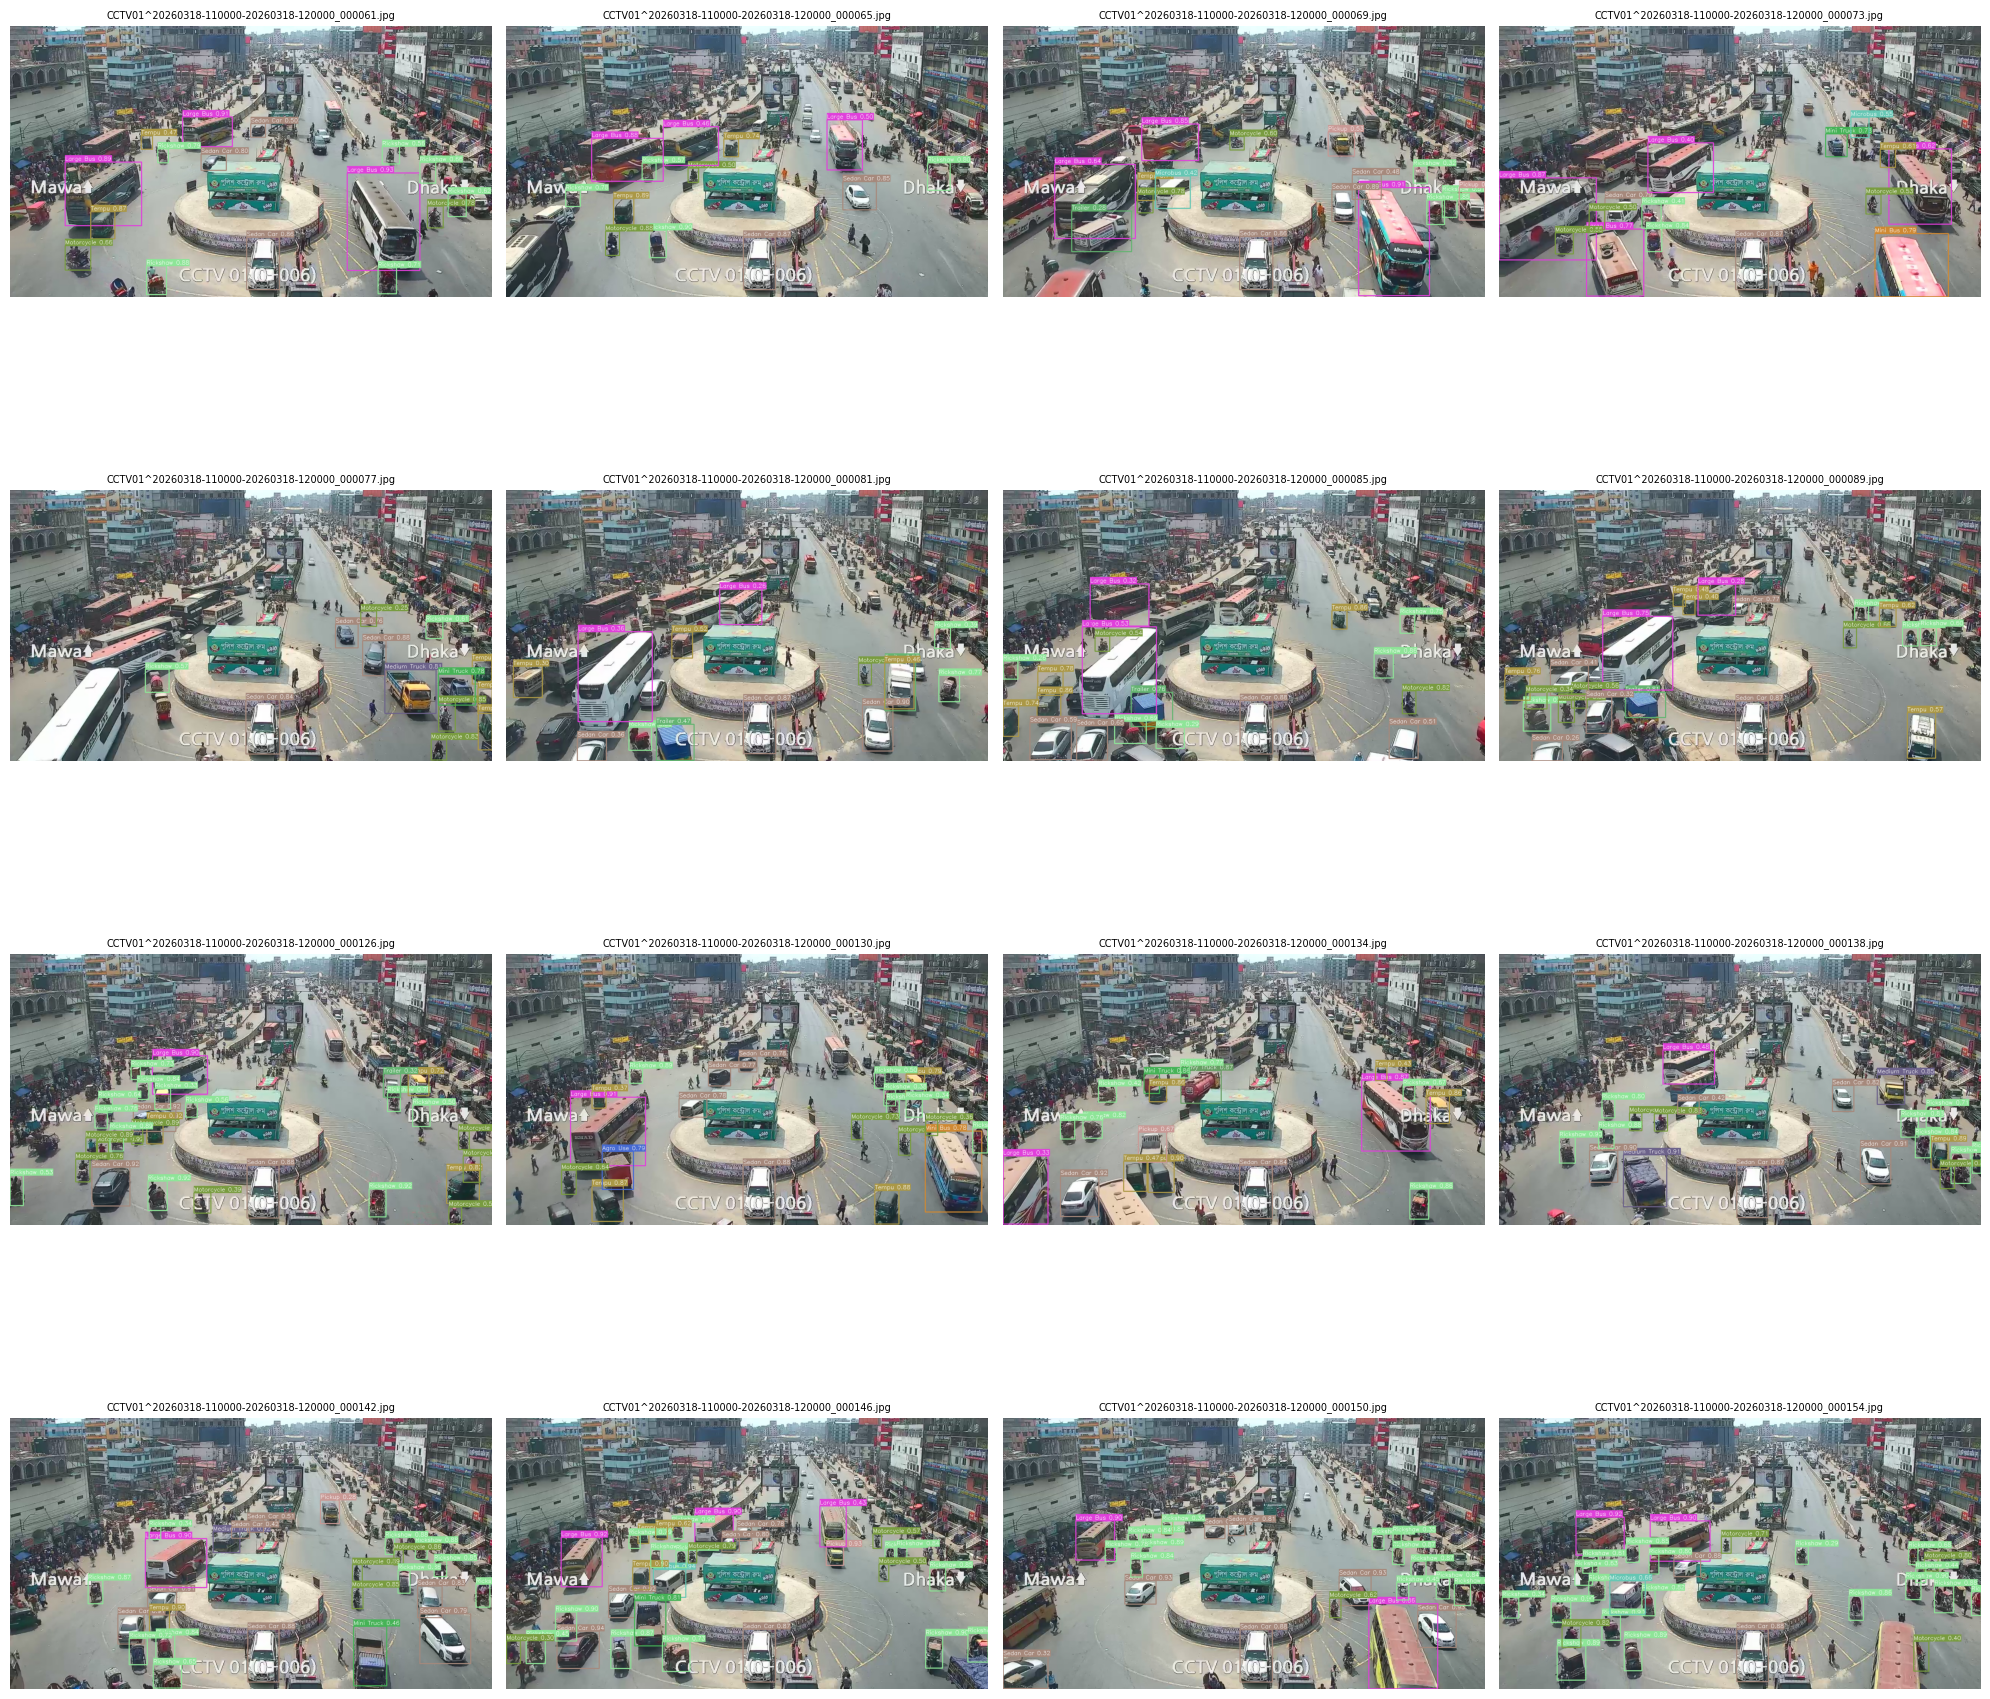

Grid saved: /kaggle/working/annotated_test_predictions/grid_16imgs.png


In [13]:
# ============================================================================
# CELL 10 — VISUALIZE TEST PREDICTIONS  (optional, runs after Cell 6)
# ============================================================================

import matplotlib.pyplot as plt

VIZ_WEIGHTS = FOLD_WEIGHTS[0] if FOLD_WEIGHTS else START_WEIGHTS
VIZ_CONF    = 0.25
VIZ_N       = 16
OUTPUT_VIZ  = "/kaggle/working/annotated_test_predictions"
os.makedirs(OUTPUT_VIZ, exist_ok=True)

np.random.seed(42)
CLASS_COLORS = {i: tuple(int(x) for x in np.random.randint(50, 230, 3)) for i in range(NC)}

def draw_boxes(img_bgr, result, conf_thr=0.25):
    out  = img_bgr.copy()
    hh, ww = out.shape[:2]
    if result.boxes is None:
        return out
    for xyxy, cf, cl in zip(
        result.boxes.xyxyn.cpu().numpy(),
        result.boxes.conf.cpu().numpy(),
        result.boxes.cls.cpu().numpy().astype(int),
    ):
        if cf < conf_thr:
            continue
        x1,y1,x2,y2 = int(xyxy[0]*ww),int(xyxy[1]*hh),int(xyxy[2]*ww),int(xyxy[3]*hh)
        color = CLASS_COLORS.get(cl, (0,255,0))
        cv2.rectangle(out, (x1,y1),(x2,y2), color, 2)
        lbl = f"{CLASS_NAMES.get(cl,'?')} {cf:.2f}"
        ts  = cv2.getTextSize(lbl, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)[0]
        cv2.rectangle(out,(x1,y1-ts[1]-6),(x1+ts[0],y1),color,-1)
        cv2.putText(out,lbl,(x1,y1-4),cv2.FONT_HERSHEY_SIMPLEX,0.5,(255,255,255),1)
    return out

from ultralytics import YOLO as _YOLO
model_viz  = _YOLO(VIZ_WEIGHTS)
sample_test = sorted(glob.glob(f"{TEST_IMG}/*.jpg"))[:VIZ_N]
results_viz = list(model_viz.predict(sample_test, imgsz=IMGSZ, conf=VIZ_CONF,
                                     stream=True, verbose=False))

cols = 4
rows = (len(results_viz) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, rows*5))
axes = axes.flatten() if rows*cols > 1 else [axes]

for idx, res in enumerate(results_viz):
    img = cv2.imread(res.path)
    ann = draw_boxes(img, res, VIZ_CONF)
    axes[idx].imshow(cv2.cvtColor(ann, cv2.COLOR_BGR2RGB))
    axes[idx].set_title(os.path.basename(res.path), fontsize=7)
    axes[idx].axis("off")

for idx in range(len(results_viz), len(axes)):
    axes[idx].axis("off")

plt.tight_layout()
grid_path = f"{OUTPUT_VIZ}/grid_{VIZ_N}imgs.png"
plt.savefig(grid_path, dpi=80)
plt.show()
print(f"Grid saved: {grid_path}")
